# 02 · Feature Engineering

Three families of engineered features, all implemented in `churn.features`:

1. **Contract-duration categories** - `tenure` bucketed into lifecycle stages.
2. **Charge ratios** - lifetime average spend and current-vs-lifetime charge.
3. **Missing-value flag** - marks the blank `TotalCharges` rows from notebook 01.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="deep")

from churn import config, data, features

df = features.engineer(data.load_clean())
new_cols = ["TotalCharges_missing", "tenure_group", "avg_charges_per_month", "monthly_vs_lifetime"]
df[new_cols].head()

,TotalCharges_missing,tenure_group,avg_charges_per_month,monthly_vs_lifetime
0,0,0-1yr,29.850000,1.000000
1,0,2-4yr,55.573529,1.024768
2,0,0-1yr,54.075000,0.995839
3,0,2-4yr,40.905556,1.034089
4,0,0-1yr,75.825000,0.932410


## Contract-duration categories
Churn drops monotonically across the engineered tenure groups.

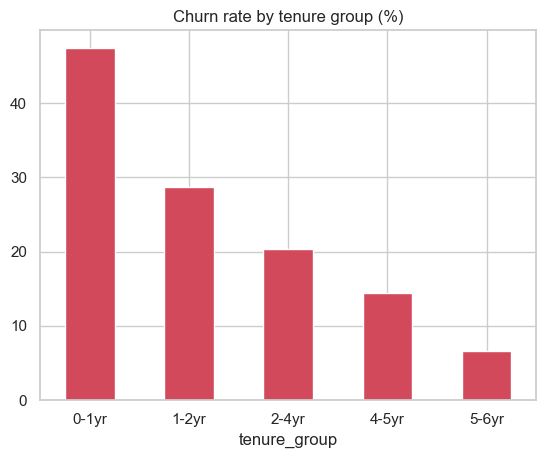

In [2]:
(df.groupby("tenure_group", observed=True)[config.TARGET].mean() * 100).reindex(
    features.TENURE_LABELS
).plot.bar(color="#d1495b", rot=0, title="Churn rate by tenure group (%)");

## Charge ratios

In [3]:
df[["avg_charges_per_month", "monthly_vs_lifetime"]].describe().round(2)

,avg_charges_per_month,monthly_vs_lifetime
count,7043.00,7043.00
mean,64.76,1.00
std,30.19,0.05
min,13.78,0.64
25%,35.94,0.98
50%,70.34,1.00
75%,90.17,1.02
max,121.40,1.45


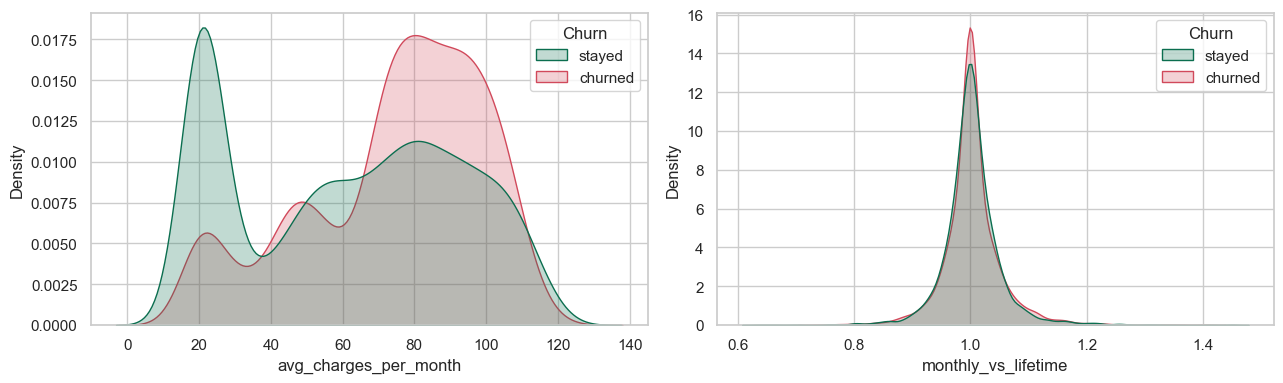

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
lab = df[config.TARGET].map({0: "stayed", 1: "churned"})
sns.kdeplot(data=df, x="avg_charges_per_month", hue=lab, fill=True, common_norm=False,
            palette=["#0b6e4f", "#d1495b"], ax=axes[0])
sns.kdeplot(data=df, x="monthly_vs_lifetime", hue=lab, fill=True, common_norm=False,
            palette=["#0b6e4f", "#d1495b"], ax=axes[1])
plt.tight_layout();

## Missing-value flag
The flagged rows (tenure 0) actually churn *less* - they are brand new.

In [5]:
print(df["TotalCharges_missing"].value_counts().to_dict())
print("churn rate | flagged:", df.loc[df.TotalCharges_missing == 1, config.TARGET].mean())
print("churn rate | others :", round(df.loc[df.TotalCharges_missing == 0, config.TARGET].mean(), 3))

{0: 7032, 1: 11}
churn rate | flagged: 0.0
churn rate | others : 0.266


## Preprocessing pipeline

`features.build_preprocessor` one-hot encodes the categoricals and (optionally,
for the linear model) standard-scales the numerics. Everything lives inside a
single sklearn `Pipeline`, so there is no train/test leakage.

In [6]:
prep = features.build_preprocessor(scale_numeric=False)
X = df[features.FEATURE_COLUMNS]
encoded = prep.fit_transform(X)
print("feature matrix after preprocessing:", encoded.shape)
print("numeric features   :", features.NUMERIC_FEATURES)
print("categorical features:", features.CATEGORICAL_FEATURES)

feature matrix after preprocessing: (7043, 48)
numeric features   : ['tenure', 'MonthlyCharges', 'TotalCharges', 'avg_charges_per_month', 'monthly_vs_lifetime', 'TotalCharges_missing']
categorical features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']
